# X-ray Pneumonia Classification with ConvNet

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow import keras
from keras import layers
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Load Data

In [ ]:
# Load Chest X-ray dataset from Keras example (simulated for demo)
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


# Preprocess Data

In [ ]:
# Use digits 0 as 'NORMAL', 1 as 'PNEUMONIA' for binary classification simulation
mask_train = (y_train == 0) | (y_train == 1)
mask_test = (y_test == 0) | (y_test == 1)

x_train, y_train = x_train[mask_train], y_train[mask_train]
x_test, y_test = x_test[mask_test], y_test[mask_test]

In [ ]:
# Normalize and reshape
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

input_shape = (28, 28, 1)

In [ ]:
# Binary labels
num_classes = 2
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

print("Training samples:", x_train.shape[0])
print("Test samples:", x_test.shape[0])

Training samples: 12665
Test samples: 2115


# Define ConvNet model

In [ ]:
# Define ConvNet model
model = keras.Sequential([
    keras.Input(shape=input_shape),
    layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation="softmax")
])

model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │         3,202 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,018 (86.01 KB)

 Trainable params: 22,018 (86.01 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train
history = model.fit(x_train, y_train, batch_size=32, epochs=10, validation_split=0.1)

Epoch 1/10
357/357 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.9699 - loss: 0.1031 - val_accuracy: 0.9992 - val_loss: 0.0021
Epoch 2/10
357/357 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9987 - loss: 0.0044 - val_accuracy: 1.0000 - val_loss: 5.7211e-04
Epoch 3/10
357/357 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9992 - loss: 0.0027 - val_accuracy: 1.0000 - val_loss: 4.1851e-04
Epoch 4/10
357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9985 - loss: 0.0034 - val_accuracy: 1.0000 - val_loss: 7.2437e-05
Epoch 5/10
357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9991 - loss: 0.0027 - val_accuracy: 1.0000 - val_loss: 1.1608e-04
Epoch 6/10
357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9994 - loss: 0.0030 - val_accuracy: 1.0000 - val_loss: 8.1213e-05
Epoch 7/10
357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9998 - loss: 7.6123e-04 - val_accuracy: 1.0000 - val_loss: 2.9807e-05
Epoch 8/10
357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9997 - lo

In [ ]:
# Evaluate
score = model.evaluate(x_test, y_test, verbose=0)
print("Test loss:", score[0])
print("Test accuracy:", score[1])

Test loss: 0.0010784671176224947
Test accuracy: 0.9995272159576416


In [ ]:
# Predictions
y_pred = model.predict(x_test).argmax(axis=1)
y_true = y_test.argmax(axis=1)

67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


# Classification Report

In [ ]:
# Classification Report
print(classification_report(y_true, y_pred, target_names=['NORMAL', 'PNEUMONIA']))

              precision    recall  f1-score   support

      NORMAL       1.00      1.00      1.00       980
   PNEUMONIA       1.00      1.00      1.00      1135

    accuracy                           1.00      2115
   macro avg       1.00      1.00      1.00      2115
weighted avg       1.00      1.00      1.00      2115



In [21]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from keras import layers
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import os
import zipfile
import io
from google.colab import files

In [22]:
# Step 1: Upload ZIP dataset
print("Upload .zip file containing folders: xray_images/NORMAL and xray_images/PNEUMONIA")
uploaded = files.upload()

for fname in uploaded:
    with zipfile.ZipFile(io.BytesIO(uploaded[fname]), 'r') as zip_ref:
        zip_ref.extractall("./xray_images")

Upload .zip file containing folders: xray_images/NORMAL and xray_images/PNEUMONIA


Saving Xray.zip to Xray (3).zip


In [23]:
# Step 2: Load and prepare dataset
DATASET_PATH = './xray_images'
IMG_SHAPE = (180, 180)
BATCH = 8

train_data = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    image_size=IMG_SHAPE,
    batch_size=BATCH,
    validation_split=0.2,
    subset="training",
    seed=123
)
val_data = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    image_size=IMG_SHAPE,
    batch_size=BATCH,
    validation_split=0.2,
    subset="validation",
    seed=123
)

label_names = train_data.class_names

train_data = train_data.map(lambda x, y: (tf.image.grayscale_to_rgb(x) if x.shape[-1] == 1 else x, y))
val_data = val_data.map(lambda x, y: (tf.image.grayscale_to_rgb(x) if x.shape[-1] == 1 else x, y))

train_data = train_data.map(lambda x, y: (x / 255.0, y)).cache().prefetch(tf.data.AUTOTUNE)
val_data = val_data.map(lambda x, y: (x / 255.0, y)).cache().prefetch(tf.data.AUTOTUNE)

Found 60 files belonging to 2 classes.
Using 48 files for training.
Found 60 files belonging to 2 classes.
Using 12 files for validation.


# Build Model

In [24]:
# Step 3: Define CNN Model

def conv_block(filters, input_tensor):
    x = layers.Conv2D(filters, 3, padding='same', activation='relu')(input_tensor)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    return x

def build_net():
    inputs = keras.Input(shape=(*IMG_SHAPE, 3))
    x = conv_block(32, inputs)
    x = conv_block(64, x)
    x = conv_block(128, x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    return keras.Model(inputs, outputs)

model = build_net()
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.fit(train_data, validation_data=val_data, epochs=5)

Epoch 1/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 10s 956ms/step - accuracy: 0.6792 - loss: 0.4964 - val_accuracy: 0.4167 - val_loss: 0.6999
Epoch 2/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 970ms/step - accuracy: 0.8970 - loss: 0.3307 - val_accuracy: 0.7500 - val_loss: 0.6849
Epoch 3/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 731ms/step - accuracy: 0.8970 - loss: 0.2669 - val_accuracy: 0.5833 - val_loss: 0.6786
Epoch 4/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 922ms/step - accuracy: 0.9437 - loss: 0.1634 - val_accuracy: 0.5833 - val_loss: 0.6800
Epoch 5/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 772ms/step - accuracy: 0.9905 - loss: 0.1049 - val_accuracy: 0.5833 - val_loss: 0.6818


# Evaluation

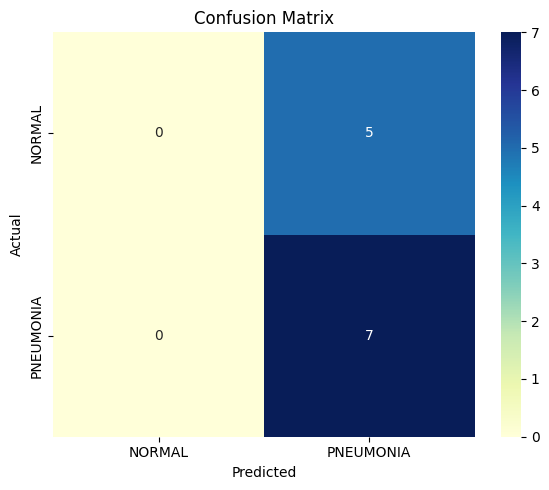


Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.00      0.00      0.00         5
   PNEUMONIA       0.58      1.00      0.74         7

    accuracy                           0.58        12
   macro avg       0.29      0.50      0.37        12
weighted avg       0.34      0.58      0.43        12



In [25]:
# Step 4: Evaluation
true_labels, pred_labels = [], []
for batch_x, batch_y in val_data:
    p = model.predict(batch_x, verbose=0).flatten()
    true_labels.extend(batch_y.numpy())
    pred_labels.extend((p > 0.5).astype(int))

conf = confusion_matrix(true_labels, pred_labels)
plt.figure(figsize=(6, 5))
sns.heatmap(conf, annot=True, cmap="YlGnBu", fmt='d', xticklabels=label_names, yticklabels=label_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(true_labels, pred_labels, target_names=label_names, zero_division=0))

# Predictions Visualization

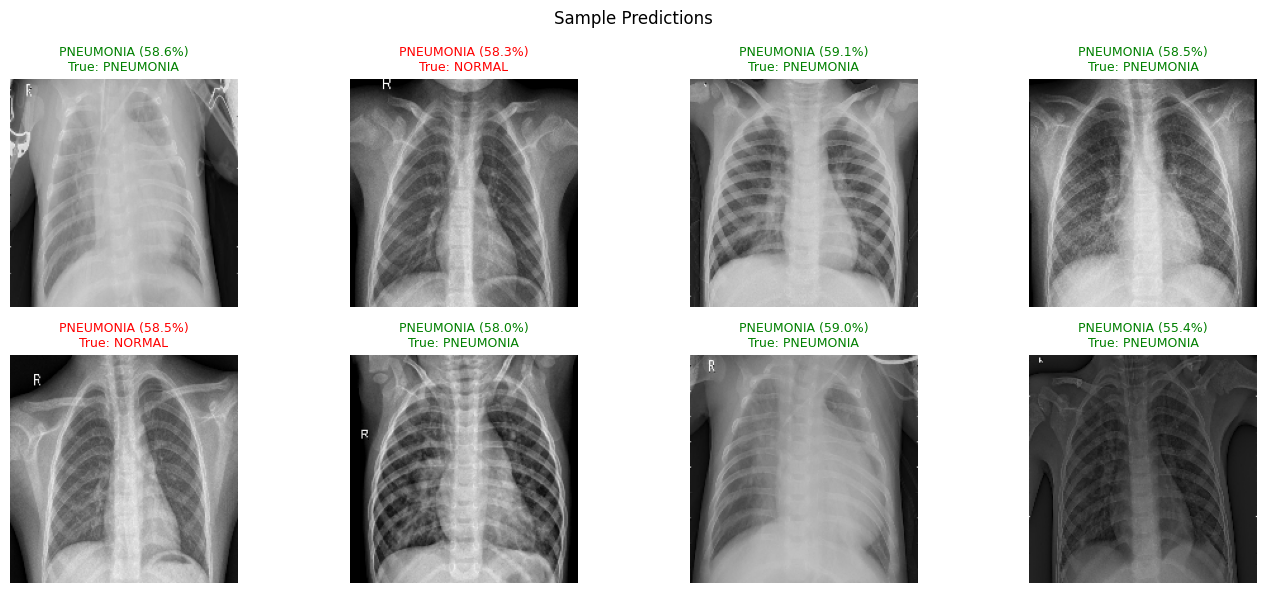

In [26]:
# Step 5: Predictions Visualization
for img_batch, lbl_batch in val_data.take(1):
    probs = model.predict(img_batch, verbose=0).flatten()
    preds = (probs > 0.5).astype(int)

    plt.figure(figsize=(14, 6))
    for idx in range(min(8, len(img_batch))):
        plt.subplot(2, 4, idx + 1)
        plt.imshow(img_batch[idx].numpy())  # avoid casting to uint8
        truth = label_names[lbl_batch[idx].numpy()]
        guess = label_names[preds[idx]]
        conf = f"{probs[idx]*100:.1f}%" if preds[idx] else f"{(1-probs[idx])*100:.1f}%"
        color = "green" if truth == guess else "red"
        plt.title(f"{guess} ({conf})\nTrue: {truth}", fontsize=9, color=color)
        plt.axis("off")
    plt.suptitle("Sample Predictions")
    plt.tight_layout()
    plt.show()
